In [1]:
import pandas as pd
import numpy as np
import requests
from io import StringIO
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import glob
import re

from tools.toolistat import load_istat_catalogue, get_istat_dataset
import tools.tooldb as tb
from tools.tooldb import clean_stat, update_json
from functools import reduce

## Italy Data

## Istat Tables

In [9]:
API_BASE = "https://esploradati.istat.it/SDMXWS/rest"

def get_available_values(id_db:str):
    """Return a dictionary with available values for each dimension in the DataSet instance"""
    url = f"{API_BASE}/availableconstraint/{id_db}?references=all&detail=full"

    response = requests.get(url)
    response.raise_for_status()
    if response.text == 'No available data found for the requested query':
        raise ValueError(f'No available data found for the requested query (dataset {id_db})')
    
    tree = ET.iterparse(StringIO(response.text))

    for _, el in tree:
        _, _, el.tag = el.tag.rpartition('}')

    root = tree.root

    dimensions_values = {}
    for dimension in root.iter("Codelist"):
        dimension_id = dimension.get("id")

        values = {}
        value_id_l, value_descr_l = [], []

        for value in dimension.iter("Code"):
            value_id = value.get("id")
            value_descr = [name.text for name in value.findall("Name")][1]
            value_id_l.append(value_id)
            value_descr_l.append(value_descr)

        values["values_ids"] = value_id_l
        values["values_description"] = value_descr_l
        dimensions_values[dimension_id] = values

    #for dimension_id in list(dimensions_values.keys()):
    #    dimension = self.get_dimension_name(dimension_id)
    #    dimensions_values[dimension] = dimensions_values.pop(dimension_id)

    return dimensions_values

In [7]:
id_db = "533_957_DF_DCSC_RACLI_10"
url = f"{API_BASE}/availableconstraint/{id_db}?references=all&detail=full"
response = requests.get(url)

ConnectTimeout: HTTPSConnectionPool(host='esploradati.istat.it', port=443): Max retries exceeded with url: /SDMXWS/rest/availableconstraint/533_957_DF_DCSC_RACLI_10?references=all&detail=full (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x11fb6b3d0>, 'Connection to esploradati.istat.it timed out. (connect timeout=None)'))

In [9]:
dataflows = load_istat_catalogue()

KeyboardInterrupt: 

In [5]:
dataflows[dataflows["df_description"].str.contains("cofog", case=False)]

,df_id,version,df_description,df_structure_id
2496,5_94_DF_DCCN_OTEPPA_B19_1,1.0,Consumption expenditure by function (COFOG 2 a...,DCCN_OTEPPA_B19
2497,5_94_DF_DCCN_OTEPPA_B19_2,1.0,Expenditure items by function (COFOG 2 and 3 d...,DCCN_OTEPPA_B19
3063,734_1061_DF_DCCN_OTEPPA_B14_1,1.0,Consumption expenditure by function (COFOG 2 a...,DCCN_OTEPPA_B1485257
3064,734_1061_DF_DCCN_OTEPPA_B14_2,1.0,Expenditure items by function (COFOG 2 and 3 d...,DCCN_OTEPPA_B1496536
3759,95_94_DF_DCCN_OTEPPA_1,1.0,Consumption expenditure by function (COFOG 2 a...,DCCN_OTEPPA
3760,95_94_DF_DCCN_OTEPPA_2,1.0,Expenditure items by function (COFOG 2 and 3 d...,DCCN_OTEPPA


In [ ]:
df_earn = get_istat_dataset(
    dataset_code="533_957_DF_DCSC_RACLI_10",
    filters="A..............",
    start_year="2013",
    end_year="2025",
    version="1.0"
)

df_earn.head()

,FREQ,REF_AREA,DATA_TYPE,SEX,AGE,EDU_LEV_HIGHEST,COUNTRY_BIRTH,CITIZENSHIP,TYPE_OF_CONTRACT,FULL_PART_TIME,CONTARCTUAL_OCCUPATION,EMPLOYEE_TENURE,PAID_DAYS,ECON_ACTIVITY_NACE_2007,EMPLOYESS_CLASS,TIME_PERIOD,OBS_VALUE
0,A,IT,HOUWAG_ENTEMP_AV_MI,9,TOTAL,99,IT,WORLD,9,9,99,TOTAL,TOTAL,10,TOTAL,2014-01-01,14.27
1,A,IT,HOUWAG_ENTEMP_AV_MI,9,TOTAL,99,IT,WORLD,9,9,99,TOTAL,TOTAL,10,TOTAL,2015-01-01,14.44
2,A,IT,HOUWAG_ENTEMP_AV_MI,9,TOTAL,99,IT,WORLD,9,9,99,TOTAL,TOTAL,10,TOTAL,2016-01-01,14.41
3,A,IT,HOUWAG_ENTEMP_AV_MI,9,TOTAL,99,IT,WORLD,9,9,99,TOTAL,TOTAL,10,TOTAL,2017-01-01,14.49
4,A,IT,HOUWAG_ENTEMP_AV_MI,9,TOTAL,99,IT,WORLD,9,9,99,TOTAL,TOTAL,10,TOTAL,2018-01-01,14.44


In [ ]:
keys = ["geo", "TIME_PERIOD"]

earn_map = {
    'HOUWAG_ENTEMP_AV_MI': 'hourwag-av',
    'HOUWAG_ENTEMP_FIRD_MI': 'hourwag-fird',
    'HOUWAG_ENTEMP_MED_MI': 'hourwag-med',
    'HOUWAG_ENTEMP_NIND_MI': 'hourwag-nind',
}

educ_map = {
    11: "upper-secondary",
    13: "tertiary",
    7: "below-upper-secondary",
    99: "total",
}

db_name = "it_earnings"
descriptions = {
    "earn-citiz": "Gross hourly earnings by country of birth per paid hour of salaried job positions in euro (average, median, 10th and 90th deciles)",
    "earn-educ": "Gross hourly earnings by education level per paid hour of salaried job positions in euro (average, median, 10th and 90th deciles)",
    "earn-cntr": "Gross hourly earnings by contract type level per paid hour of salaried job positions in euro (average, median, 10th and 90th deciles)",
    "earn-hou": "Gross hourly earnings by regime (full-time or part-time) level per paid hour of salaried job positions in euro (average, median, 10th and 90th deciles)",
    "earn-empl": "Gross hourly earnings by employee class level per paid hour of salaried job positions in euro (average, median, 10th and 90th deciles)",
    "earn-qual": "Gross hourly earnings by contractual qualification level per paid hour of salaried job positions in euro (average, median, 10th and 90th deciles)",
    "earn-sex": "Gross hourly earnings by sex level per paid hour of salaried job positions in euro (average, median, 10th and 90th deciles)",
    "earn-age": "Gross hourly earnings by age group level per paid hour of salaried job positions in euro (average, median, 10th and 90th deciles)",
}

database_infos = {
    # original_db_name : (filters, measure_column, prefix, suffix, pattern)
    "533_957_DF_DCSC_RACLI_10" : ("A..............", ["DATA_TYPE", "COUNTRY_BIRTH"], "earn-brth", "", ["name", "unit", "citiz"]),
    "533_957_DF_DCSC_RACLI_11" : ("A..............", ["DATA_TYPE", "EDU_LEV_HIGHEST"], "earn-educ", "", ["name", "unit", "educ"]),
    "533_957_DF_DCSC_RACLI_12" : ("A..............", ["DATA_TYPE", "TYPE_OF_CONTRACT"], "earn-cntr", "", ["name", "unit", "contr"]),
    "533_957_DF_DCSC_RACLI_13" : ("A..............", ["DATA_TYPE", "FULL_PART_TIME"], "earn-hou", "", ["name", "unit", "hour"]),
    "533_957_DF_DCSC_RACLI_14" : ("A..............", ["DATA_TYPE", "EMPLOYESS_CLASS"], "earn-empl", "", ["name", "unit", "empl"]),
    "533_957_DF_DCSC_RACLI_15" : ("A..............", ["DATA_TYPE", "CONTARCTUAL_OCCUPATION"], "earn-qual", "", ["name", "unit", "qual"]),
    "533_957_DF_DCSC_RACLI_8" : ("A..............", ["DATA_TYPE", "SEX"], "earn-sex", "", ["name", "unit", "sex"]),
    "533_957_DF_DCSC_RACLI_9" : ("A..............", ["DATA_TYPE", "AGE"], "earn-age", "", ["name", "unit", "age"]),
}

earn_dfs = {}
dbs_list = [db for db in database_infos.keys()]

for i, db in enumerate(dbs_list):
    filters, measure_columns, prefix, suffix, pattern = database_infos.get(db)
    measure_columns = measure_columns if isinstance(measure_columns, (list, tuple)) else [measure_columns]
    df = get_istat_dataset(
        dataset_code=db,
        filters=filters,
        start_year="2013",
        end_year="2025",
        version="1.0"
    )

    df["EDU_LEV_HIGHEST"] = df["EDU_LEV_HIGHEST"].map(educ_map)

    df["DATA_TYPE"] = df["DATA_TYPE"].map(earn_map)
    df = df.rename(columns={"REF_AREA": "geo"})
    
    string_cols = df.select_dtypes(include="object").columns
    df[string_cols] = df[string_cols].apply(
        lambda s: s.str.replace("_", "-", regex=False)
    )
    df = clean_stat(df, keys=keys, columns_to_pivot=measure_columns, prefix=f'{prefix}_')

    earn_dfs[i+1] = df

    if db in descriptions:
        update_json(df, db_name, pattern, descriptions[db])

earnings_df = reduce(lambda left, right: pd.merge(left, right, on=["geo", "time_period"], how="outer"), earn_dfs.values())


In [8]:
earnings_df

,geo,time_period,earn-brth_hourwag-av_it,earn-brth_hourwag-av_world,earn-brth_hourwag-av_wrl-x-ita,earn-brth_hourwag-fird_it,earn-brth_hourwag-fird_world,earn-brth_hourwag-fird_wrl-x-ita,earn-brth_hourwag-med_it,earn-brth_hourwag-med_world,...,earn-age_hourwag-fird_y15-29,earn-age_hourwag-fird_y30-49,earn-age_hourwag-med_total,earn-age_hourwag-med_y-ge50,earn-age_hourwag-med_y15-29,earn-age_hourwag-med_y30-49,earn-age_hourwag-nind_total,earn-age_hourwag-nind_y-ge50,earn-age_hourwag-nind_y15-29,earn-age_hourwag-nind_y30-49
0,IT,2014-01-01,14.27,13.8,11.35,8.05,7.85,7.17,11.38,11.06,...,7.10,8.08,11.06,12.39,9.76,11.34,20.67,26.36,14.00,20.52
1,IT,2015-01-01,14.44,14.01,11.73,8.13,7.96,7.4,11.51,11.21,...,7.25,8.16,11.21,12.52,9.90,11.45,20.93,26.31,14.38,20.68
2,IT,2016-01-01,14.41,13.97,11.74,8.16,8.0,7.44,11.51,11.21,...,7.24,8.20,11.21,12.48,9.92,11.46,20.83,26.05,14.35,20.60
3,IT,2017-01-01,14.49,14.04,11.82,8.17,8.03,7.56,11.53,11.25,...,7.31,8.24,11.25,12.46,10.03,11.49,20.93,26.19,14.59,20.69
4,IT,2018-01-01,14.44,13.98,11.76,8.15,8.01,7.55,11.55,11.27,...,7.26,8.24,11.27,12.40,10.06,11.51,20.81,25.86,14.71,20.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1204,ITG28,2022-01-01,12.3,12.27,11.85,8.55,8.55,8.53,11.03,11.01,...,8.02,8.70,11.01,11.60,10.28,11.10,15.72,17.50,13.69,15.52
1205,ITG29,2014-01-01,11.65,11.48,10.33,8.01,7.94,7.54,10.34,10.24,...,7.48,8.12,10.24,10.94,9.61,10.39,15.05,18.58,12.79,14.98
1206,ITG2A,2014-01-01,11.4,11.41,11.57,7.98,7.96,7.81,10.31,10.27,...,7.47,8.14,10.27,11.04,9.71,10.31,14.68,17.94,12.57,14.37
1207,ITG2B,2014-01-01,11.18,11.16,10.19,7.71,7.71,7.76,10.1,10.09,...,7.20,7.79,10.09,10.81,9.34,10.19,14.45,18.15,12.07,14.05


In [12]:
ti.get_available_values("EDU_LEV_HIGHEST")

HTTPError: 500 Server Error: Internal Server Error for url: https://esploradati.istat.it/SDMXWS/rest/availableconstraint/EDU_LEV_HIGHEST/all/all?mode=available

## Static Tables

In [243]:
inps_transfer_df = pd.read_csv('staticTables/Italy/italy_inps_transfer.csv', sep=';')
inps_transfer_df.head()

,Anno,Entrate_contributive,Trasferimenti_Stato,Trasf_oneri_pensionistici,Trasf_oneri_mantenimento_ salario,Trasf_oneri_mantenimento_famiglia,Trasf_oneri_prestazioni_econ_da riduzioni_oneri previdenziali,Trasf_oneri_sgravi_oneri_sociali_e_agevolazioni,Trasf_oneri_interventi_diversi,Trasf_oneri_reddito_pensione_cittadinanza
0,2011,210572,84806,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012,208076,94131,63805.0,8333.0,3671.0,696.0,16018.0,1278.0,0.0
2,2013,210141,99396,67989.0,9592.0,3992.0,677.0,15488.0,1338.0,0.0
3,2014,211462,98440,67454.0,10387.0,3856.0,656.0,14832.0,1255.0,0.0
4,2015,214787,103773,72172.0,8794.0,4033.0,622.0,15897.0,2255.0,0.0


In [ ]:
pens_df = pd.read_csv('staticTables/Italy/italy_pens.csv', sep=';')
pens_df.head()

,year,vecch_num,vecch_importo,inv_num,inv_imp,surv_num,surv_imp,complex_num,complex_imp,inv_x100_vecch
0,1980,3265816,1686,3115267,1333,2088839,921,8469922,1368,95
1,1981,3361325,2191,3138821,1707,2133824,1156,8633970,1759,93
2,1982,3470190,2585,3141763,2016,2192795,1394,8804748,2085,91
3,1983,3585748,3158,3113218,2466,2223369,1676,8922335,2547,87
4,1984,3728603,3499,2981895,2667,2282057,1847,8992555,2804,80


In [ ]:
reg_exp_df = pd.read_csv('staticTables/Italy/italy_regional_exp.csv', sep=';')
reg_exp_df.head()

# Add population by age by region by year

,Territorio,Regione per Dettaglio,Settore,Categoria Spese,Anno,S - Consolidato SPA
0,91 - Centro-Nord,01 - Piemonte,00001 - Amministrazione Generale,S - 445 - TOTALE SPESA,2000.0,"4075,3653900000"
1,91 - Centro-Nord,01 - Piemonte,00001 - Amministrazione Generale,S - 445 - TOTALE SPESA,2001.0,"4666,3544300000"
2,91 - Centro-Nord,01 - Piemonte,00001 - Amministrazione Generale,S - 445 - TOTALE SPESA,2002.0,"4415,0920200000"
3,91 - Centro-Nord,01 - Piemonte,00001 - Amministrazione Generale,S - 445 - TOTALE SPESA,2003.0,"5594,5320300000"
4,91 - Centro-Nord,01 - Piemonte,00001 - Amministrazione Generale,S - 445 - TOTALE SPESA,2004.0,"6079,8312500000"


In [251]:
tax_brackets_df = pd.read_csv('staticTables/Italy/italy_tax_brackets.csv', sep=';')
tax_brackets_df.head()

,year,threshold_higher,tax_rate
0,1985,5681.03,18.0
1,1985,12394.97,27.0
2,1985,15493.71,35.0
3,1985,19625.36,37.0
4,1985,30987.41,41.0


In [16]:
tax_br_df = pd.read_csv('staticTables/Italy/italy_tax_brackets.csv', sep=';')


/var/folders/_s/3l81jppx5y5bjk_zkh9m6bdw0000gn/T/ipykernel_1542/3392970929.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('RdBu', len(years))


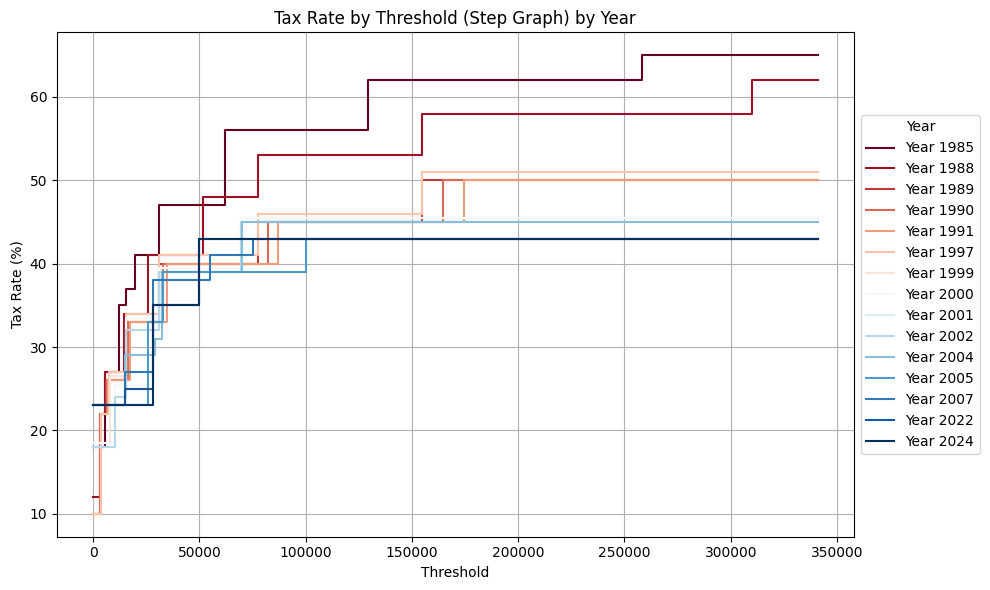

In [42]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Prepare figure
plt.figure(figsize=(10,6))

# Colormap: red -> blue
years = tax_br_df['year'].unique()
colors = cm.get_cmap('RdBu', len(years))

# Loop over years
for idx, y in enumerate(years):
    df_year = tax_br_df[tax_br_df['year'] == y].copy()
    
    df_year['threshold_numeric'] = df_year['threshold_numeric'].fillna(max_thresh)
    
    x = []
    y_values = []

    thresholds = df_year['threshold_numeric'].values
    rates = df_year['tax_rate'].values

    x.append(0)
    y_values.append(rates[0])

    for i in range(len(thresholds)):
        x.append(thresholds[i])
        y_values.append(rates[i])
        
        if i < len(thresholds) - 1:
            x.append(thresholds[i])
            y_values.append(rates[i+1])
    
    plt.step(x, y_values, where='post', color=colors(idx), label=f'Year {y}')

plt.xlabel('Threshold')
plt.ylabel('Tax Rate (%)')
plt.title('Tax Rate by Threshold (Step Graph) by Year')
plt.grid(True)

# Legend outside on the right, vertical
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='Year')

plt.tight_layout()  # prevent clipping of legend
plt.show()


/var/folders/_s/3l81jppx5y5bjk_zkh9m6bdw0000gn/T/ipykernel_1542/162291670.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('RdBu', len(years))


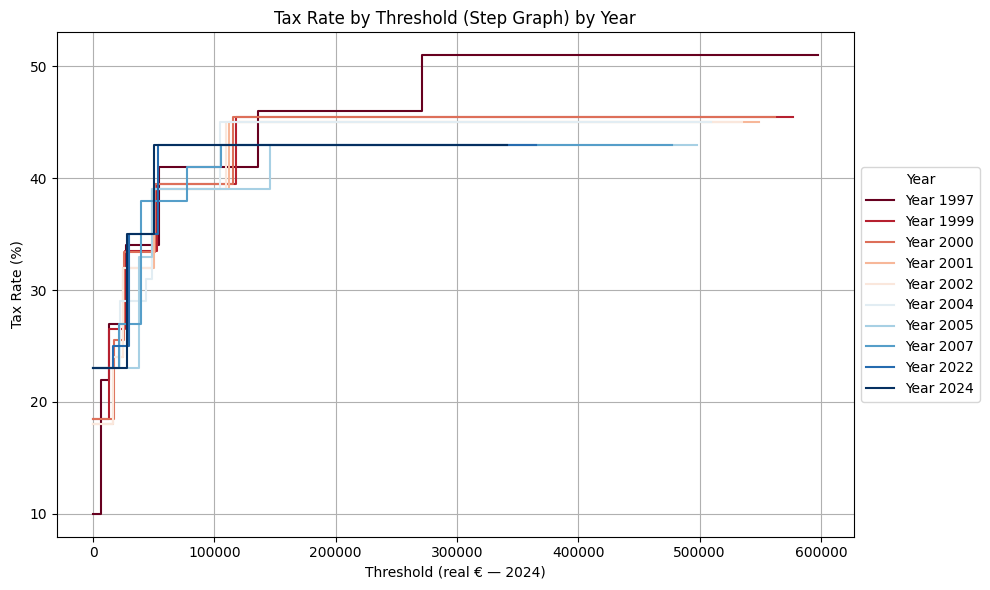

In [41]:
# ---------- ADD: HICP dictionary (year -> index) ----------
hicp_dict = {
    1996: 68.5, 1997: 69.8, 1998: 71.2, 1999: 72.3, 2000: 74.2,
    2001: 75.9, 2002: 77.9, 2003: 80.1, 2004: 81.9, 2005: 83.7,
    2006: 85.6, 2007: 87.3, 2008: 90.4, 2009: 91.1, 2010: 92.6,
    2011: 95.3, 2012: 98.4, 2013: 99.7, 2014: 99.9, 2015: 100.0,
    2016: 99.9, 2017: 101.3, 2018: 102.5, 2019: 103.2, 2020: 103.0,
    2021: 105.0, 2022: 114.2, 2023: 120.9, 2024: 122.3
}
ref_year = 2024
hicp_ref = hicp_dict[ref_year]
years = sorted([y for y in tax_br_df['year'].unique() if y >= 1996])
# ----------------------------------------------------------

# Prepare figure
plt.figure(figsize=(10,6))

# Colormap: red -> blue
colors = cm.get_cmap('RdBu', len(years))

# Loop over years
for idx, y in enumerate(years):
    df_year = tax_br_df[tax_br_df['year'] == y].copy()
    
    df_year['threshold_numeric'] = df_year['threshold_numeric'].fillna(max_thresh)
    
    # ---------- ADD: compute real thresholds in 2024 euros ----------
    if y not in hicp_dict:
        raise KeyError(f'HICP index for year {y} not found in hicp_dict.')
    multiplier = hicp_ref / hicp_dict[y]
    df_year['threshold_real'] = df_year['threshold_numeric'] * multiplier
    # Use the real thresholds for plotting
    thresholds = df_year['threshold_real'].values
    # --------------------------------------------------------------
    
    y_values = []

    rates = df_year['tax_rate'].values

    x = []
    x.append(0)
    y_values.append(rates[0])

    for i in range(len(thresholds)):
        x.append(thresholds[i])
        y_values.append(rates[i])
        
        if i < len(thresholds) - 1:
            x.append(thresholds[i])
            y_values.append(rates[i+1])
    
    plt.step(x, y_values, where='post', color=colors(idx), label=f'Year {y}')

plt.xlabel('Threshold (real € — 2024)')
plt.ylabel('Tax Rate (%)')
plt.title('Tax Rate by Threshold (Step Graph) by Year')
plt.grid(True)

# Legend outside on the right, vertical
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='Year')

plt.tight_layout()  # prevent clipping of legend
plt.show()

/var/folders/_s/3l81jppx5y5bjk_zkh9m6bdw0000gn/T/ipykernel_1542/1296148692.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdBu', len(years))


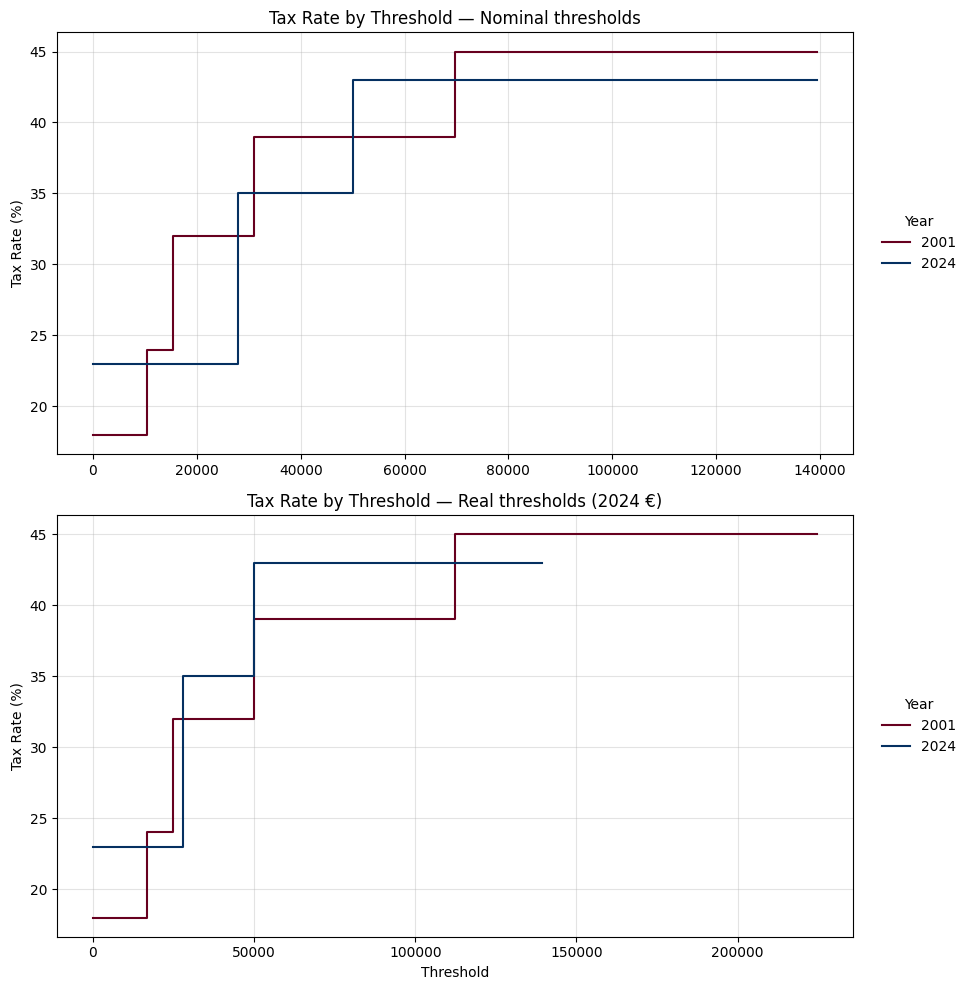

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

tax_br_df = pd.read_csv('staticTables/Italy/italy_tax_brackets.csv', sep=';')
# ---------- HICP dictionary (year -> index) ----------
hicp_dict = {
    1996: 68.5, 1997: 69.8, 1998: 71.2, 1999: 72.3, 2000: 74.2,
    2001: 75.9, 2002: 77.9, 2003: 80.1, 2004: 81.9, 2005: 83.7,
    2006: 85.6, 2007: 87.3, 2008: 90.4, 2009: 91.1, 2010: 92.6,
    2011: 95.3, 2012: 98.4, 2013: 99.7, 2014: 99.9, 2015: 100.0,
    2016: 99.9, 2017: 101.3, 2018: 102.5, 2019: 103.2, 2020: 103.0,
    2021: 105.0, 2022: 114.2, 2023: 120.9, 2024: 122.3
}
ref_year = 2024
hicp_ref = hicp_dict[ref_year]
# ------------------------------------------------------

# Ensure thresholds numeric column exists and is parsed
tax_br_df['threshold_numeric'] = pd.to_numeric(tax_br_df['threshold_higher'], errors='coerce')

# Keep only years >= 1996
tax_br_df = tax_br_df[tax_br_df['year'] >= 1996].copy()
tax_br_df = tax_br_df[(tax_br_df['year'] == 2001) | (tax_br_df['year'] == 2024)].copy()

# Sort rows
tax_br_df.sort_values(by=['year', 'threshold_numeric'], inplace=True)

# Prepare years and max threshold for handling 'over'
years = sorted(tax_br_df['year'].unique())
max_thresh = tax_br_df['threshold_numeric'].max(skipna=True) * 2

# Prepare colormap
cmap = cm.get_cmap('RdBu', len(years))

# Prepare figure with two subplots (nominal on top, real below)
fig, (ax_nom, ax_real) = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=False)

for idx, y in enumerate(years):
    df_year = tax_br_df[tax_br_df['year'] == y].copy()
    df_year['threshold_numeric'] = df_year['threshold_numeric'].fillna(max_thresh)
    rates = df_year['tax_rate'].values

    # ---- Nominal thresholds (as-is) ----
    thresholds_nom = df_year['threshold_numeric'].values

    x_nom = [0.0]
    y_nom = [rates[0]]
    for i in range(len(thresholds_nom)):
        x_nom.append(thresholds_nom[i])
        y_nom.append(rates[i])
        if i < len(thresholds_nom) - 1:
            x_nom.append(thresholds_nom[i])
            y_nom.append(rates[i+1])

    ax_nom.step(x_nom, y_nom, where='post', color=cmap(idx), label=str(y), linewidth=1.5)

    # ---- Real thresholds (inflation-adjusted to 2024 €) ----
    if y not in hicp_dict:
        # skip years without HICP entry (shouldn't happen for >=1996 with given dict)
        continue
    multiplier = hicp_ref / hicp_dict[y]
    thresholds_real = thresholds_nom * multiplier

    x_real = [0.0]
    y_real = [rates[0]]
    for i in range(len(thresholds_real)):
        x_real.append(thresholds_real[i])
        y_real.append(rates[i])
        if i < len(thresholds_real) - 1:
            x_real.append(thresholds_real[i])
            y_real.append(rates[i+1])

    ax_real.step(x_real, y_real, where='post', color=cmap(idx), label=str(y), linewidth=1.5)

# Axes formatting
ax_nom.set_ylabel('Tax Rate (%)')
ax_nom.set_title('Tax Rate by Threshold — Nominal thresholds')
ax_nom.grid(True, alpha=0.35)

ax_real.set_xlabel('Threshold')
ax_real.set_ylabel('Tax Rate (%)')
ax_real.set_title('Tax Rate by Threshold — Real thresholds (2024 €)')
ax_real.grid(True, alpha=0.35)

# Legends: place vertical legends outside to the right for each subplot
# For many years the legend may be long; we repeat it for both axes to be explicit.
ax_nom.legend(title='Year', loc='center left', bbox_to_anchor=(1.02, 0.5), ncol=1, frameon=False)
ax_real.legend(title='Year', loc='center left', bbox_to_anchor=(1.02, 0.5), ncol=1, frameon=False)

plt.tight_layout(rect=[0, 0, 0.82, 1])  # leave space on right for legends
plt.show()
